# **Beyond the Recipe: Predicting Baking Success Using Machine Learning and Human Factors**

# Background

Baking results are usually assumed to depend on recipe complexity and technical factors such as oven temperature and baking time. However, baking is also influenced by the baker’s emotional state and environment, including stress levels, distractions, time pressure, and kitchen conditions. These non-technical factors may affect focus and execution, leading to baking failures even when recipes are followed correctly.

# Problem Statement

Build a machine learning model that predicts baking outcomes (Success/Fail) using recipe characteristics, environmental conditions, and baker-related factors to determine whether human and environmental factors predict baking failure more strongly than recipe complexity.

# Objectives

1. Predict baking outcomes using a binary classification model (Success/Fail).

2. Identify the most important factors contributing to baking failure.

3. Compare the influence of recipe complexity versus baker stress and environmental conditions on baking outcomes.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, average_precision_score

# Load the Dataset

In [ ]:
df = pd.read_csv('Baking Dataset.csv')
df.head()

,Session,Recipe Complexity Level (1-5),Recipe Familiarity,Oven Temperature (Celcius),Baking Time (Minutes),Time of Day,Kitchen Temperature (Celcius),Humidity Level,Baker Stress Level,Time Pressured?,Music Playing?,Distraction Level,Outcome,Texture Score (1-5)\n5 being the highest,Baker satisfaction Score (1-5)\n5 being the highest
0,1,1,Repeated,179,38,Morning,30.0,63,Medium,No,Yes,Medium,Fail,3,1
1,2,4,Repeated,202,35,Afternoon,26.9,77,Low,No,Yes,Low,Success,3,4
2,3,4,First time,194,30,Night,27.9,82,Medium,No,Yes,Low,Fail,2,2
3,4,3,Repeated,172,29,Night,27.7,72,Medium,Yes,No,Medium,Fail,2,2
4,5,3,Repeated,183,27,Morning,25.9,59,High,No,No,High,Fail,2,2


# Exploratory Data Analysis

# Target Distribution

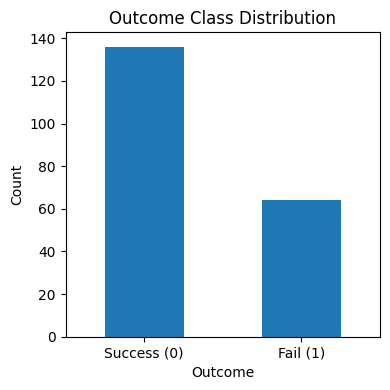

In [ ]:
plt.figure(figsize=(4, 4))
df['Outcome'].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["Success (0)", "Fail (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Outcome Class Distribution")
plt.tight_layout()
plt.show()

# Data Diagnosis

In [ ]:
rows = []
missing_pct = df.isna().mean().mul(100).round(2)

for col in df.columns:
    s = df[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v
    })

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Session,200,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",identifier,0.0,NaN,NaN,NaN
1,Recipe Complexity Level (1-5),5,"[1, 4, 3, 5, 2]",numeric,0.0,1.0,5.0,3.0450
2,Recipe Familiarity,2,"[Repeated, First time]",binary,0.0,NaN,NaN,NaN
3,Oven Temperature (Celcius),53,"[179, 202, 194, 172, 183, 180, 161, 182, 185, ...",numeric,0.0,151.0,214.0,178.4250
4,Baking Time (Minutes),33,"[38, 35, 30, 29, 27, 33, 25, 34, 24, 20]",numeric,0.0,10.0,48.0,27.0100
5,Time of Day,3,"[Morning, Afternoon, Night]",categorical,0.0,NaN,NaN,NaN
6,Kitchen Temperature (Celcius),94,"[30.0, 26.9, 27.9, 27.7, 25.9, 29.7, 29.6, 29....",numeric,0.0,20.6,34.8,28.1165
7,Humidity Level,46,"[63, 77, 82, 72, 59, 58, 54, 73, 83, 49]",numeric,0.0,45.0,95.0,70.3750
8,Baker Stress Level,3,"[Medium, Low, High]",categorical,0.0,NaN,NaN,NaN
9,Time Pressured?,2,"[No, Yes]",binary,0.0,NaN,NaN,NaN


Insights

1. The dataset is complete with no missing values, enabling straightforward analysis without data imputation or loss.
2. Several variables capture the baking environment and process (oven temperature, kitchen temperature, humidity, baking time), which are likely key drivers of the final outcome.
3. The data combines objective measurements (temperature, time, humidity) with human and behavioral factors (stress level, time pressure, music, distractions).
4. Many features use low-range ordinal scales (1–5 ratings, low/medium/high), making them easy to interpret but sensitive to threshold effects.
5. The binary Outcome (Fail/Success) is well-defined, supporting classification analysis to understand which conditions lead to successful baking.

# Features Identification

In [ ]:
# Target
target_col = ["Outcome"]

# Drop (Constants and Identifiers)
drop_col = ["Session", "Texture Score (1-5)\n5 being the highest",
    "Baker satisfaction Score (1-5)\n5 being the highest"]

# Categorical Features
cat_cols = ["Time of Day", "Baker Stress Level", "Distraction Level",
    "Recipe Familiarity", "Time Pressured?", "Music Playing?"]

# Ordinal Features
ord_cols = ["Recipe Complexity Level (1-5)"]

# Numerical Features
num_cols = ["Oven Temperature  (Celcius)", "Baking Time (Minutes)",
    "Kitchen Temperature (Celcius)", "Humidity Level"]

# Feature Type Conversions

In [ ]:
df = df.copy()

# Target
df[target_col[0]] = df[target_col[0]].map({"Fail": 1, "Success": 0})

# Drop
df = df.drop(columns=drop_col, errors="ignore")

# Categorical
for col in cat_cols:
    df[col] = df[col].astype("category")

# Ordinal
for col in ord_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Numerical
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_type_converted = df.copy()
df_type_converted.head()

,Recipe Complexity Level (1-5),Recipe Familiarity,Oven Temperature (Celcius),Baking Time (Minutes),Time of Day,Kitchen Temperature (Celcius),Humidity Level,Baker Stress Level,Time Pressured?,Music Playing?,Distraction Level,Outcome
0,1,Repeated,179,38,Morning,30.0,63,Medium,No,Yes,Medium,1
1,4,Repeated,202,35,Afternoon,26.9,77,Low,No,Yes,Low,0
2,4,First time,194,30,Night,27.9,82,Medium,No,Yes,Low,1
3,3,Repeated,172,29,Night,27.7,72,Medium,Yes,No,Medium,1
4,3,Repeated,183,27,Morning,25.9,59,High,No,No,High,1


# Correlations

# Categorical Features vs Target

In [ ]:
from scipy.stats import chi2_contingency

alpha = 0.05
cat_results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df_type_converted[col], df_type_converted["Outcome"])
    _, p_value, _, _ = chi2_contingency(contingency_table)

    cat_results.append({
        "Feature": col,
        "P-Value": p_value,
        "Decision": "Retain" if p_value < alpha else "Drop"
    })

cat_vs_target = (
    pd.DataFrame(cat_results)
    .sort_values("P-Value")
    .reset_index(drop=True)
)

cat_vs_target

,Feature,P-Value,Decision
0,Music Playing?,2.897705e-07,Retain
1,Baker Stress Level,4.681322e-04,Retain
2,Distraction Level,1.633526e-02,Retain
3,Time of Day,1.766360e-01,Drop
4,Recipe Familiarity,1.954313e-01,Drop
5,Time Pressured?,4.936919e-01,Drop


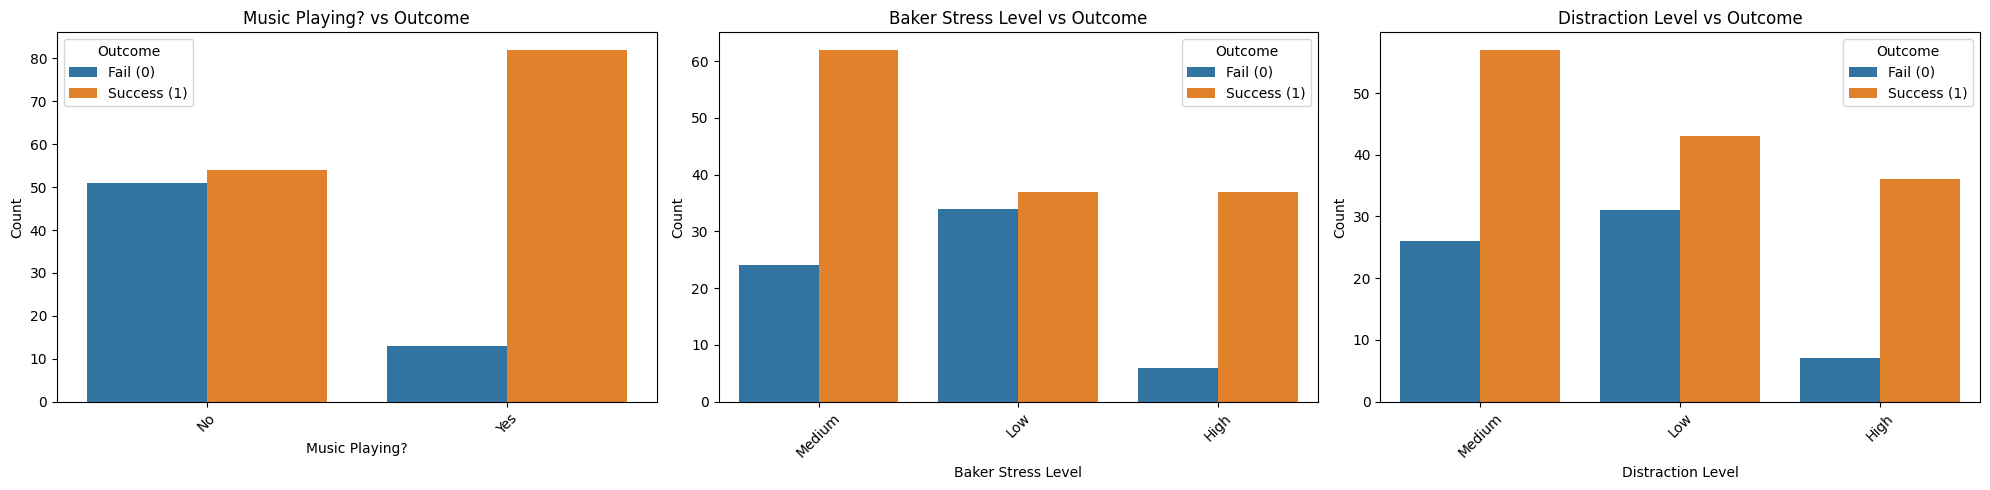

In [ ]:
cat_top3 = [
    "Music Playing?",
    "Baker Stress Level",
    "Distraction Level"
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col in zip(axes, cat_top3):

    order = (
        df_type_converted[col]
        .value_counts()
        .sort_values(ascending=False)
        .index
    )

    sns.countplot(
        data=df_type_converted,
        x=col,
        hue="Outcome",
        order=order,
        ax=ax
    )

    ax.set_title(f"{col} vs Outcome")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Outcome", labels=["Fail (0)", "Success (1)"])

plt.tight_layout()
plt.show()

Insights
1. Playing music while baking is associated with higher success, with noticeably more successful outcomes when music is on.
2. Lower baker stress levels correspond to better outcomes, while high stress shows fewer successful bakes.
3. High distraction levels are linked to lower success, with failures more common when distractions are high.
4. Across all three factors, behavioral conditions matter, not just technical baking settings.
5. Creating a calm, focused baking environment appears to significantly improve the likelihood of success.

# Ordinal Features vs Target

In [ ]:
from scipy.stats import mannwhitneyu
import pandas as pd

alpha = 0.05
ord_results = []

for col in ord_cols:
    group_0 = df_type_converted[df_type_converted["Outcome"] == 0][col].dropna()
    group_1 = df_type_converted[df_type_converted["Outcome"] == 1][col].dropna()

    _, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    ord_results.append({
        "Feature": col,
        "P-Value": p_value,
        "Decision": "Retain" if p_value < alpha else "Drop"
    })

ord_vs_target = (
    pd.DataFrame(ord_results)
    .sort_values("P-Value")
    .reset_index(drop=True)
)

ord_vs_target

,Feature,P-Value,Decision
0,Recipe Complexity Level (1-5),0.799185,Drop


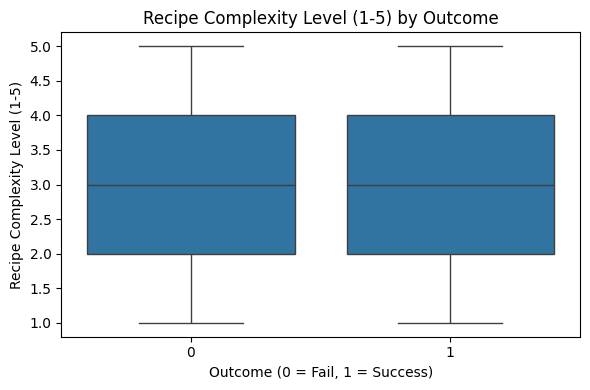

In [ ]:
ord_top1 = ["Recipe Complexity Level (1-5)"]

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df_type_converted,
    x="Outcome",
    y=ord_top1[0],
    ax=ax
)

ax.set_title(f"{ord_top1[0]} by Outcome")
ax.set_xlabel("Outcome (0 = Fail, 1 = Success)")
ax.set_ylabel(ord_top1[0])

plt.tight_layout()
plt.show()

Insights

1. Recipe complexity shows nearly identical distributions for failed and successful bakes, with similar medians.
2. There is strong overlap across all complexity levels, indicating little separation between outcomes.
3. On its own, recipe complexity has limited predictive value for baking success.

# Numerical Features vs Target

In [ ]:
alpha = 0.05

num_corr = (
    df_type_converted[num_cols + ["Outcome"]]
    .corr()["Outcome"]
    .drop("Outcome")
)

num_vs_target = (
    num_corr
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

num_vs_target.columns = ["Feature", "Abs_Correlation"]

num_vs_target["Decision"] = num_vs_target["Abs_Correlation"].apply(
    lambda x: "Retain" if x >= alpha else "Drop"
)

num_vs_target

,Feature,Abs_Correlation,Decision
0,Humidity Level,0.101536,Retain
1,Baking Time (Minutes),0.088003,Retain
2,Kitchen Temperature (Celcius),0.004227,Drop
3,Oven Temperature (Celcius),0.001661,Drop


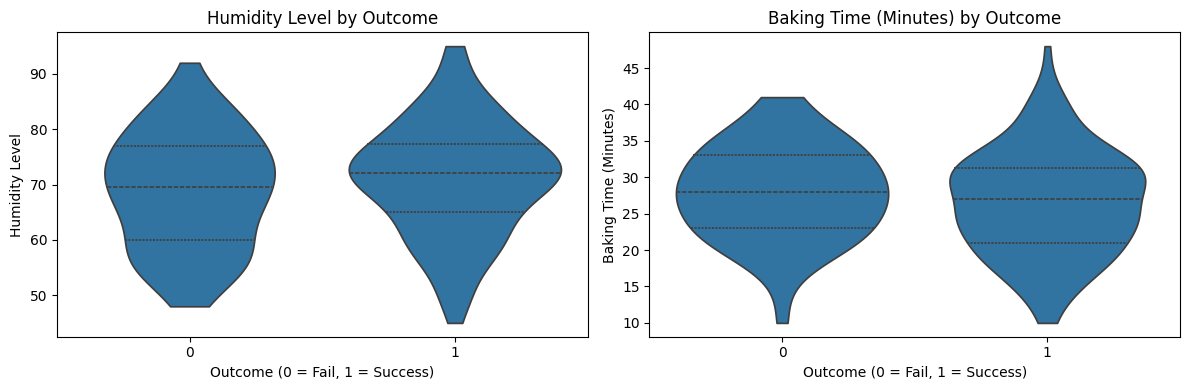

In [ ]:
num_top2 = [
    "Humidity Level",
    "Baking Time (Minutes)"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, num_top2):
    sns.violinplot(
        data=df_type_converted,
        x="Outcome",
        y=col,
        ax=ax,
        inner="quartile",
        cut=0
    )
    ax.set_title(f"{col} by Outcome")
    ax.set_xlabel("Outcome (0 = Fail, 1 = Success)")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

Insights

1. Successful bakes tend to occur at slightly higher humidity levels, suggesting moisture plays a role in achieving good results.
2. Failed bakes show a wider spread in humidity, indicating less consistent environmental conditions.
3. Baking time for successful outcomes is more concentrated, while failures show greater variability in time spent baking.
4. Very short or very long baking times are more common among failed bakes, highlighting the importance of timing control.
5. Overall, environmental consistency (humidity and timing) appears to be a key factor in baking success.

# Selected Columns

In [ ]:
cat_cols_selected = (cat_vs_target.loc[cat_vs_target["Decision"] == "Retain", "Feature"].tolist())
ord_cols_selected = (ord_vs_target.loc[ord_vs_target["Decision"] == "Retain", "Feature"].tolist())
num_cols_selected = (num_vs_target.loc[num_vs_target["Decision"] == "Retain", "Feature"].tolist())

drop_cols_selected = (
    cat_vs_target.loc[cat_vs_target["Decision"] == "Drop", "Feature"].tolist()
    + ord_vs_target.loc[ord_vs_target["Decision"] == "Drop", "Feature"].tolist()
    + num_vs_target.loc[num_vs_target["Decision"] == "Drop", "Feature"].tolist()
)

selected_cols = (cat_cols_selected + ord_cols_selected + num_cols_selected + target_col)
df_selected = df_type_converted[selected_cols].copy()
df_selected.head()

,Music Playing?,Baker Stress Level,Distraction Level,Humidity Level,Baking Time (Minutes),Outcome
0,Yes,Medium,Medium,63,38,1
1,Yes,Low,Low,77,35,0
2,Yes,Medium,Low,82,30,1
3,No,Medium,Medium,72,29,1
4,No,High,High,59,27,1


# Encoding Categorical Features

In [ ]:
df_encoded = pd.get_dummies(df_selected, columns=cat_cols_selected, drop_first=True, dtype=int)
df_encoded.head()

,Humidity Level,Baking Time (Minutes),Outcome,Music Playing?_Yes,Baker Stress Level_Low,Baker Stress Level_Medium,Distraction Level_Low,Distraction Level_Medium
0,63,38,1,1,0,1,0,1
1,77,35,0,1,1,0,1,0
2,82,30,1,1,0,1,1,0
3,72,29,1,0,0,1,0,1
4,59,27,1,0,0,0,0,0


# Normalization

In [ ]:
df_norm = df_encoded.copy()

scale_cols = num_cols_selected + ord_cols_selected
scaler = StandardScaler()
df_norm[scale_cols] = scaler.fit_transform(df_norm[scale_cols])

df_norm.head()

,Humidity Level,Baking Time (Minutes),Outcome,Music Playing?_Yes,Baker Stress Level_Low,Baker Stress Level_Medium,Distraction Level_Low,Distraction Level_Medium
0,-0.720226,1.573054,1,1,0,1,0,1
1,0.646983,1.143649,0,1,1,0,1,0
2,1.135271,0.427974,1,1,0,1,1,0
3,0.158694,0.284839,1,0,0,1,0,1
4,-1.110857,-0.001431,1,0,0,0,0,0


# Train - Test Split

In [ ]:
X = df_norm.drop(columns=target_col)
y = df_norm[target_col[0]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Model Training

In [ ]:
k_values = range(1, 31)

accuracy_scores = []
pr_auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    y_proba = knn.predict_proba(X_test)[:, 1]

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    pr_auc_scores.append(average_precision_score(y_test, y_proba))

# Evaluation

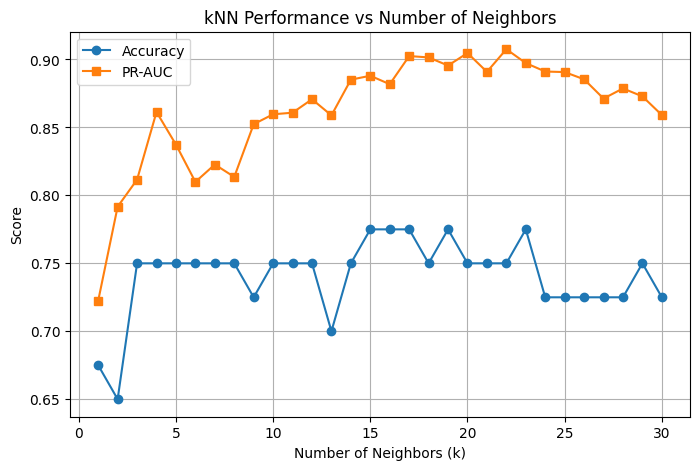

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker="o", label="Accuracy")
plt.plot(k_values, pr_auc_scores, marker="s", label="PR-AUC")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Score")
plt.title("kNN Performance vs Number of Neighbors")
plt.legend()
plt.grid(True)
plt.show()

Insights
1. PR-AUC improves as k increases and peaks in the mid-range (around k ≈ 18–22), indicating better ranking of positive cases.
2. Accuracy is relatively flat across most k values, showing it is less sensitive to neighborhood size in this dataset.
3. Very small k values are unstable, leading to lower and noisier performance.
4. Very large k values begin to dilute signal, slightly reducing PR-AUC as neighborhoods become too broad.
5. A moderate k provides the best trade-off between stability and performance, justifying the selected k for the final model.